# Assignment 1: Opinion Network Formation

In this notebook, we are constructing a respondent-based network from the survey dataset, `Survey_Results_UC.csv`. Conceptually, this process shares the same underlying logic used when mapping structural connectomes or calculating distance metrics for a k-nearest neighbors classifier: we are transforming behavioral data into a multidimensional feature space to identify structural clusters.

Here, each respondent serves as a distinct node, and the edges will be determined by the mathematical similarity of their survey answers across the four domains (Technology, Education, Society, Environment).

### Step 1: Vectorization and Missing-Data Policy
The raw data consists of text-based Likert-scale responses. Before we can compute a similarity matrix or isolate sub-graphs, we must encode these string values into a numerical format.

In the execution block below, we will:
1. Load `Survey_Results_UC.csv` into a pandas DataFrame.
2. Construct a mapping dictionary to convert ordinal text (e.g., "Strongly Disagree" to "Strongly Agree") into integer values (1 through 5). `"No Comments"` maps to the neutral value 3, because selecting it is a deliberate answer rather than a non-response.
3. **Leave blank cells as NaN.** They are not imputed. An earlier version of this pipeline filled every blank with the neutral value 3, which manufactured structure: the four respondents who answered only the Technology block received 45 identical filler values each and became artificially similar to one another. Treating blanks as genuinely missing avoids inventing opinions nobody expressed.
4. **Drop respondents who answered nothing at all.** An all-blank row carries no information, and with no answers there is no basis on which to correlate them with anyone.


In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('Survey_Results_UC.csv')

# 2. Define the Likert scale mapping dictionary.
#    'No Comments' is an explicit choice, so it maps to the neutral value 3.
#    Blank cells are absent from this mapping and therefore become NaN.
likert_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5,
    'No Comments': 3
}

# 3. Apply the mapping to all survey columns.
#    The first column is 'id. Response ID', so we isolate the question columns.
survey_cols = df.columns[1:]
df_numeric = df.copy()

for col in survey_cols:
    df_numeric[col] = df_numeric[col].map(likert_mapping)

# 4. Missing-data policy: blanks stay NaN, entirely blank respondents are dropped.
answered = df_numeric[survey_cols].notna().sum(axis=1)
empty_ids = [int(r) for r in df_numeric.loc[answered == 0, 'id. Response ID']]
df_numeric = df_numeric[answered > 0].reset_index(drop=True)

print(f"Blank cells left as NaN: {int(df[survey_cols].isna().sum().sum())} "
      f"of {df.shape[0] * len(survey_cols)}")
print(f"Dropped {len(empty_ids)} entirely blank respondents: {empty_ids}")

# 5. Extract the final feature matrix for network construction. It contains NaN.
features = df_numeric[survey_cols].to_numpy(dtype=float)
respondent_ids = df_numeric['id. Response ID'].values

answered_valid = df_numeric[survey_cols].notna().sum(axis=1)
print(f"\nRetained {features.shape[0]} respondents across {features.shape[1]} questions.")
print(f"Items answered per respondent: min {answered_valid.min()}, "
      f"max {answered_valid.max()}")
display(df_numeric.head())


Blank cells left as NaN: 505 of 5760
Dropped 5 entirely blank respondents: [44, 60, 68, 73, 78]

Retained 91 respondents across 60 questions.
Items answered per respondent: min 15, max 60


,id. Response ID,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.,T05. Artificial Intelligence will significantly accelerate scientific discovery.,T06. Most repetitive jobs will eventually be replaced by intelligent automation.,T07. Robots should replace humans in hazardous occupations whenever possible.,T08. AI-assisted diagnosis should become routine in healthcare.,T09. Autonomous vehicles will ultimately make transportation safer.,...,"V06. Water conservation should be a priority in households, institutions, and industries.",V07. Protecting biodiversity is essential for long-term human well-being.,V08. Universities should adopt environmentally sustainable campus practices even if implementation costs increase.,"V09. Products should be designed to encourage reuse, repair, and recycling.",V10. Consumers should consider environmental impact when purchasing products.,V11. Technological innovation is essential for addressing environmental challenges.,V12. Environmental sustainability should be integrated into higher education curricula.,V13. Companies should be held accountable for the environmental impacts of their activities.,V14. International cooperation is necessary to effectively address environmental challenges.,V15. Current generations have a responsibility to protect natural resources for future generations.
0,11,4.0,4.0,3.0,5.0,5.0,4.0,4.0,2.0,3.0,...,3.0,4.0,3.0,5.0,3.0,3.0,3.0,4.0,4.0,3.0
1,12,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,...,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0
2,13,4.0,5.0,3.0,2.0,5.0,4.0,5.0,4.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,4.0
3,14,3.0,4.0,3.0,4.0,4.0,4.0,3.0,4.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,4.0
4,16,3.0,4.0,5.0,5.0,1.0,5.0,5.0,4.0,3.0,...,4.0,5.0,4.0,5.0,3.0,4.0,3.0,5.0,5.0,4.0


### Step 2: Similarity Matrix and Edge Formation

To transform isolated survey rows into a structured network, we must quantify the ideological distance between every pair of respondents. Just as distance metrics define proximity in a k-nearest neighbors classifier, we use the **Pearson correlation coefficient** to establish our edges.

Because the feature matrix now contains NaN, cosine similarity cannot be applied directly — it has no definition for missing components. We therefore use **pairwise-complete Pearson correlation**: each pair of respondents is correlated over only the items that *both* answered, and each vector is centred on that shared subset.

The similarity between respondent $i$ and respondent $j$, over their shared answered items $S_{ij}$, is

$$r_{ij} = \frac{\sum_{k \in S_{ij}} (v_{ik} - \bar{v}_i)(v_{jk} - \bar{v}_j)}{\sqrt{\sum_{k \in S_{ij}} (v_{ik} - \bar{v}_i)^2}\sqrt{\sum_{k \in S_{ij}} (v_{jk} - \bar{v}_j)^2}}$$

Centring matters for the same reason it did before. Raw Likert scores run from 1 to 5, so all vectors sit in the positive orthant; an uncentred cosine would score a respondent who answered "Strongly Disagree" to everything as highly similar to one who answered "Strongly Agree" to everything, since both vectors point in the same general direction. Subtracting each respondent's mean makes disagreement and agreement genuinely opposed. On complete rows this measure is mathematically identical to the mean-centred cosine similarity, so the change affects only the incomplete rows.

We require at least `MIN_OVERLAP` shared items before correlating a pair, so that a tie can never rest on a handful of coincidental matches. Structurally, this methodology mirrors the construction of functional connectomes in network neuroscience, where edges are formed by thresholding correlation strength between regional signals. We apply a threshold $\tau$ to filter out weak, noisy correlations.


Shared answered items across 4095 pairs: min 15, median 60, max 60
Pairs below the MIN_OVERLAP=10 floor: 0

Network built with 88 nodes and 946 edges (Threshold: 0.4).
Removed 3 isolated respondents: [119, 120, 123]


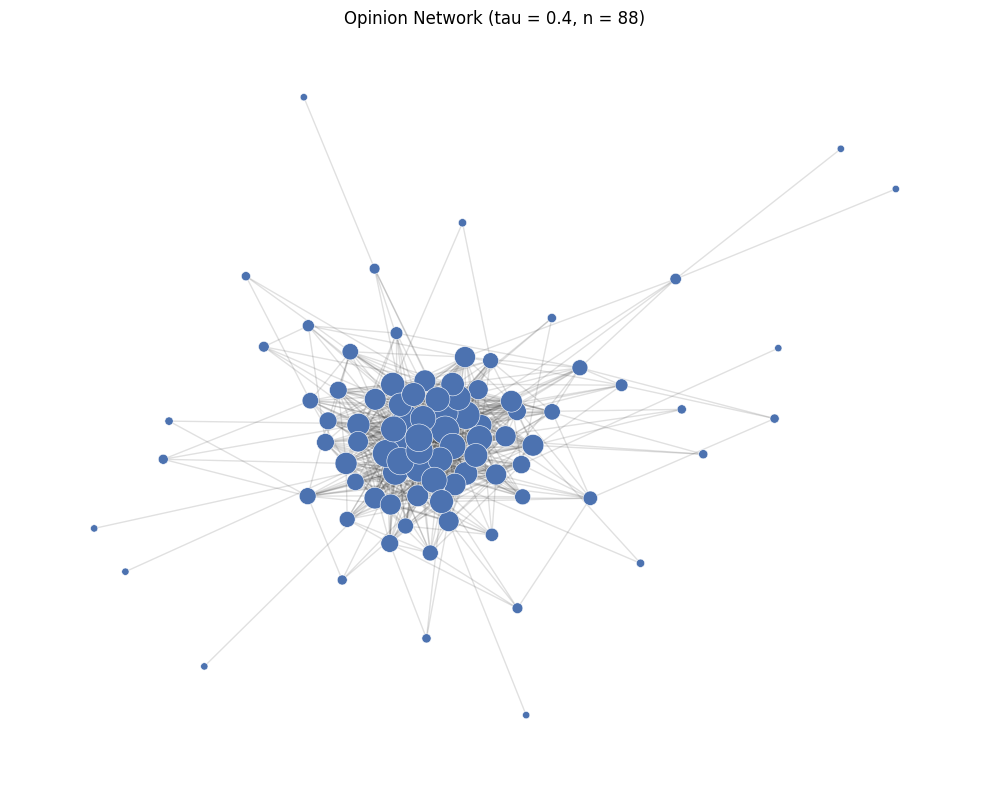

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

MIN_OVERLAP = 10   # shared answered items required before a pair is correlated

# 1. Pairwise-complete Pearson correlation.
#    Transposing puts respondents in the columns, so .corr() correlates every
#    respondent pair using only the items both of them answered.
sim_matrix = (pd.DataFrame(features.T)
              .corr(method='pearson', min_periods=MIN_OVERLAP)
              .to_numpy())

# Remove self-loops, and zero out any pair that fell below the overlap floor.
np.fill_diagonal(sim_matrix, 0)
sim_matrix = np.nan_to_num(sim_matrix, nan=0.0)

# Report the overlap actually available, so the correlations can be judged.
present = ~np.isnan(features)
overlap = present.astype(int) @ present.astype(int).T
iu = np.triu_indices(len(features), k=1)
print(f"Shared answered items across {len(overlap[iu])} pairs: "
      f"min {overlap[iu].min()}, median {int(np.median(overlap[iu]))}, "
      f"max {overlap[iu].max()}")
print(f"Pairs below the MIN_OVERLAP={MIN_OVERLAP} floor: "
      f"{(overlap[iu] < MIN_OVERLAP).sum()}")

# 2. Define Threshold and Create Adjacency Matrix.
#    A threshold of 0.4 captures strong alignments without oversaturating the graph.
tau = 0.40
adj_matrix = (sim_matrix >= tau).astype(int)

# 3. Construct the Graph
G = nx.from_numpy_array(adj_matrix)

# Map the integer nodes back to the actual Respondent IDs for accurate tracking
node_mapping = {i: respondent_ids[i] for i in range(len(respondent_ids))}
G = nx.relabel_nodes(G, node_mapping)

# Remove isolated nodes (respondents who share no strong similarity with anyone)
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

print(f"\nNetwork built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges "
      f"(Threshold: {tau}).")
print(f"Removed {len(isolated_nodes)} isolated respondents: "
      f"{sorted(int(n) for n in isolated_nodes)}")

# 4. Basic Visualisation
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='#333333')
nx.draw_networkx_nodes(G, pos, node_size=[20 + 8 * G.degree(v) for v in G.nodes()],
                       node_color='#4C72B0', linewidths=0.4, edgecolors='white')
plt.title(f'Opinion Network (tau = {tau}, n = {G.number_of_nodes()})')
plt.axis('off')
plt.tight_layout()
plt.show()
